# XGBoost vs. Linear Regression

**Problem it solves:** shows *why* you'd reach for a model like XGBoost instead of plain linear regression — not as a rule of thumb, but by watching both fail and succeed on the same data.

**How it works:** linear regression can only draw a straight line (or flat plane) through the data — one weight per feature, no interactions. XGBoost builds many small decision trees in sequence, each one correcting the previous trees' errors, so it can carve out non-linear regions and feature interactions a straight line can't represent.

**When to use which:** linear regression when the relationship really is roughly linear and you need an interpretable, fast, hard-to-overfit model. XGBoost when the relationship has non-linear effects or interactions between features — at the cost of interpretability and a real risk of overfitting if left unchecked (we'll deliberately overfit it in this notebook so you can see what that looks like).

## Step 1 — Data with a non-linear interaction, on purpose

We build the target `y` from `x1` and `x2` using a **kink** (the slope of `x1` changes sign depending on whether `x1` is positive or negative), a **curve** (`sin(x2)`), and an **interaction term** (`x1 * x2`, where the effect of one feature depends on the value of the other). A straight line literally cannot represent any of these three things — that's the point.

Train size: 1600 Val size: 400


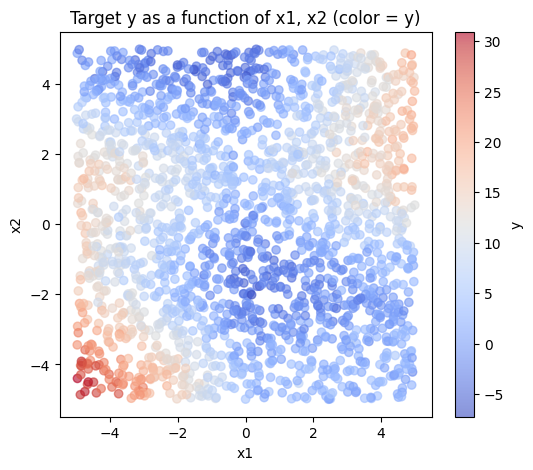

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

rng = np.random.default_rng(7)
n = 2000

x1 = rng.uniform(-5, 5, n)
x2 = rng.uniform(-5, 5, n)

y = (
    np.where(x1 > 0, x1 * 2, x1 * -3)  # kink: slope flips sign at x1=0
    + np.sin(x2) * 4  # curve
    + 0.5 * x1 * x2  # interaction: effect of x1 depends on x2
    + rng.normal(0, 1.5, n)  # noise
)

X = np.column_stack([x1, x2])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", len(X_train), "Val size:", len(X_val))

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(x1, x2, c=y, cmap="coolwarm", alpha=0.6)
plt.colorbar(sc, label="y")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Target y as a function of x1, x2 (color = y)")
plt.show()

## Step 2 — Baseline: Linear Regression

We fit the simplest model there is and check RMSE (root mean squared error — same units as `y`, easy to read) on both the training set and a held-out validation set it never saw.

In [2]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


lin = LinearRegression().fit(X_train, y_train)
lin_train_rmse = rmse(y_train, lin.predict(X_train))
lin_val_rmse = rmse(y_val, lin.predict(X_val))

print(f"Linear Regression — train RMSE: {lin_train_rmse:.3f}, val RMSE: {lin_val_rmse:.3f}")
print(f"Learned coefficients: {lin.coef_}, intercept: {lin.intercept_:.3f}")

Linear Regression — train RMSE: 6.346, val RMSE: 6.164
Learned coefficients: [-0.49556417 -0.22254686], intercept: 6.221


Notice: train RMSE (~6.3) and val RMSE (~6.2) are close to each other — but both are *bad*. That's the signature of **high bias / underfitting**: the model isn't overfitting the noise, it's simply too simple to represent the pattern at all. No amount of more data would fix this — the model itself needs to change.

## Step 3 — XGBoost, with reasonable settings

Same data, same train/val split. XGBoost gets to build 200 small trees, each fixing the previous ones' mistakes, with a modest max depth (4) that limits how complex each individual tree can get.

In [3]:
xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

xgb_train_rmse = rmse(y_train, xgb.predict(X_train))
xgb_val_rmse = rmse(y_val, xgb.predict(X_val))

print(f"XGBoost — train RMSE: {xgb_train_rmse:.3f}, val RMSE: {xgb_val_rmse:.3f}")
print()
print(f"{'Model':<20}{'Train RMSE':>12}{'Val RMSE':>12}")
print(f"{'Linear Regression':<20}{lin_train_rmse:>12.3f}{lin_val_rmse:>12.3f}")
print(f"{'XGBoost':<20}{xgb_train_rmse:>12.3f}{xgb_val_rmse:>12.3f}")

XGBoost — train RMSE: 1.149, val RMSE: 1.645

Model                 Train RMSE    Val RMSE
Linear Regression          6.346       6.164
XGBoost                    1.149       1.645


## Step 4 — Now deliberately overfit XGBoost

Same data again, but this time: very deep trees (depth 12 instead of 4), a much higher learning rate, and 1000 rounds instead of 200 — nothing here is regularizing the model, so it's free to memorize the training set, including its noise.

In [4]:
xgb_overfit = XGBRegressor(n_estimators=1000, max_depth=12, learning_rate=0.3, random_state=42)
xgb_overfit.fit(X_train, y_train)

of_train_rmse = rmse(y_train, xgb_overfit.predict(X_train))
of_val_rmse = rmse(y_val, xgb_overfit.predict(X_val))

print(f"{'Model':<25}{'Train RMSE':>12}{'Val RMSE':>12}{'Gap':>10}")
print(f"{'Linear Regression':<25}{lin_train_rmse:>12.3f}{lin_val_rmse:>12.3f}{lin_val_rmse - lin_train_rmse:>10.3f}")
print(f"{'XGBoost (regularized)':<25}{xgb_train_rmse:>12.3f}{xgb_val_rmse:>12.3f}{xgb_val_rmse - xgb_train_rmse:>10.3f}")
print(f"{'XGBoost (overfit)':<25}{of_train_rmse:>12.3f}{of_val_rmse:>12.3f}{of_val_rmse - of_train_rmse:>10.3f}")

Model                      Train RMSE    Val RMSE       Gap
Linear Regression               6.346       6.164    -0.182
XGBoost (regularized)           1.149       1.645     0.496
XGBoost (overfit)               0.123       1.969     1.847


Look at the **gap** column, not just the val RMSE. The overfit model's train RMSE drops close to zero — it has nearly memorized the training set — but its val RMSE is *worse* than the regularized model's, and the train/val gap is much bigger. That gap is the signature of **high variance / overfitting**: great on data it's seen, worse on data it hasn't. This is the bias-variance trade-off from the README made concrete: the regularized XGBoost sits in a better spot than either the too-simple linear model (high bias) or the too-flexible overfit model (high variance).

## Your turn — modify and debug on purpose

Guess the outcome before running each change.

1. Remove the interaction term (`+ 0.5 * x1 * x2`) from `y` in Step 1 and re-run everything. Does linear regression's val RMSE get better or worse? Why?
2. In Step 3, change `max_depth=4` to `max_depth=2`. Does XGBoost's val RMSE get better or worse than the depth-4 version? What does that tell you about how much complexity this data actually needs?
3. In Step 4, try `n_estimators=1000, max_depth=3` (deep rounds, shallow trees) instead of `max_depth=12` — does that overfit as badly? Why might shallow-but-many differ from deep-but-many?
4. In your own words (no AI help), write 2–3 sentences answering: *what problem does XGBoost solve that linear regression can't, and what's the cost of reaching for it?*